In [1]:
import rasterio as rio
import geopandas as gpd 
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.image as mpimg
from matplotlib.colors import LinearSegmentedColormap

In [2]:
path_ygp = 'data/boundary/ygp_region.gpkg'
path_dem = 'data/dem/SRTMGL3_300m_ygp.tif'
path_lake = 'data/lakes_ygp/HydroLAKES_ygp.gpkg'     
path_river = 'data/river/sword_reaches_ygp.gpkg'
path_basin_ygp = 'data/boundary/hydro_basin_lev04_ygp_clip.gpkg'


In [3]:
ygp_gdf = gpd.read_file(path_ygp)
lake_ygp_gdf = gpd.read_file(path_lake)
river_ygp_gdf = gpd.read_file(path_river)
basin_ygp_gdf = gpd.read_file(path_basin_ygp)  
dem_ygp = rio.open(path_dem)

In [4]:
## raster data processing
geo_extent = [dem_ygp.bounds.left, dem_ygp.bounds.right, dem_ygp.bounds.bottom, dem_ygp.bounds.top]
dem_ygp_arr = dem_ygp.read(1).astype('float32')
dem_ygp_arr[dem_ygp_arr ==0] = float('nan')  # 将值为0的像素设置为NaN


### lakes and rivers

In [ ]:
# colors = [(128/255, 205/255, 193/255), 
#           (245/255, 245/255, 245/255),
#           (223/255, 194/255, 125/255), 
#           (166/255, 97/255, 26/255)]
colors = [
    (65/255, 105/255, 225/255),   # 深湖蓝 
    # (173/255, 216/255, 230/255),  # 淡蓝色 
    (230/255, 220/255, 170/255),  # 草甸金 
    (210/255, 180/255, 140/255),  # 荒漠黄 
    (185/255, 150/255, 120/255),  # 丘陵棕 
    (150/255, 120/255, 100/255),  # 山地褐 
    (180/255, 175/255, 170/255),  # 裸岩灰 
    (210/255, 210/255, 210/255),  # 积雪灰
    (245/255, 245/255, 245/255)   # 冰川白
] 
cmap_dem = LinearSegmentedColormap.from_list('linear color', colors) 

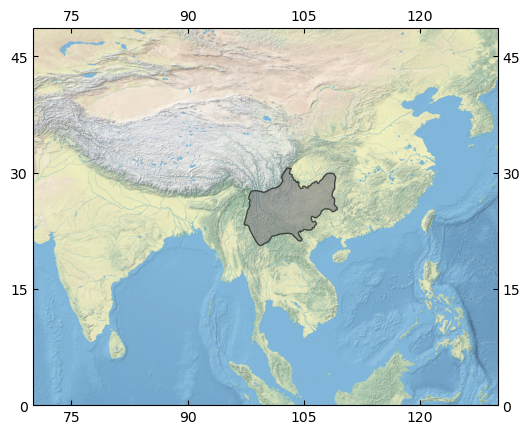

In [7]:
img = mpimg.imread("data/basemap/natural-earth-1_large4096px.png")
region = [96, 107.5, 20.5, 30]
# fig = plt.figure(figsize=(6, 6))
# ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
fig, ax = plt.subplots(figsize=(6, 6), 
                       subplot_kw={'projection': ccrs.PlateCarree()})
plt.rcParams.update({'font.size':10})
ax.set_extent([70, 130, 0, 45.0])
### plot ygp boundary
gridl = ax.gridlines(draw_labels=False, linewidth=0.)
ygp_gdf.plot(ax=ax, edgecolor='black', facecolor="#818283", linewidth=1, alpha=0.6)
### plot rectangle
ax.tick_params(labelbottom=True, labeltop=True, labelleft=True, labelright=True,
                     bottom=True, top=True, left=True, right=True, direction="in")                     
### plot auxlliary data
# ax.add_feature(cfeature.LAND, facecolor='WhiteSmoke')
# ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.5)
# ax.add_feature(cfeature.OCEAN)
# ax.stock_img()
ax.imshow(img, origin="upper",  
          extent=[-180, 180, -90, 90],  
          transform=ccrs.PlateCarree()) 
### Set figure
ax.set_xticks([75, 90, 105, 120])
ax.set_yticks([0, 15, 30, 45])
gridl.xlabel_style = {'size': 10}
gridl.ylabel_style = {'size': 10} 
# fig.savefig('figs/loc_ygp.png', dpi=300, bbox_inches='tight')

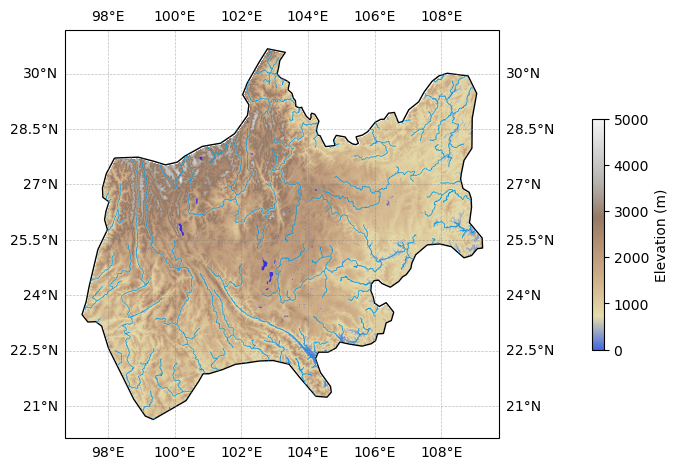

In [8]:
projection = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': projection})
plt.rcParams.update({'font.size':10})
geo_extent_expanded = [geo_extent[0] - 0.5, geo_extent[1] + 0.5, 
                       geo_extent[2] - 0.5, geo_extent[3] + 0.5]
ax.set_extent(geo_extent_expanded, crs=projection)
ax.imshow(dem_ygp_arr, cmap=cmap_dem, extent=geo_extent, transform=projection, vmax=5000, vmin=0)
ygp_gdf.plot(ax=ax, facecolor='none', edgecolor='black', transform=projection)
lake_ygp_gdf.plot(ax=ax, color='blue', alpha=0.7, transform=projection)
river_ygp_gdf.plot(ax=ax, color="#0498E2" , linewidth=0.5, transform=projection)
ax.gridlines(draw_labels=True, linewidth=0.5, 
                      color='gray', alpha=0.5, linestyle='--') 
cbar = fig.colorbar(ax.images[-1], ax=ax, orientation='vertical', shrink=0.5, pad=0.15)
cbar.set_label('Elevation (m)')
# fig.savefig('figs/ygp.png', dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'Lakes with Area > 20 km², number of lakes: 18')

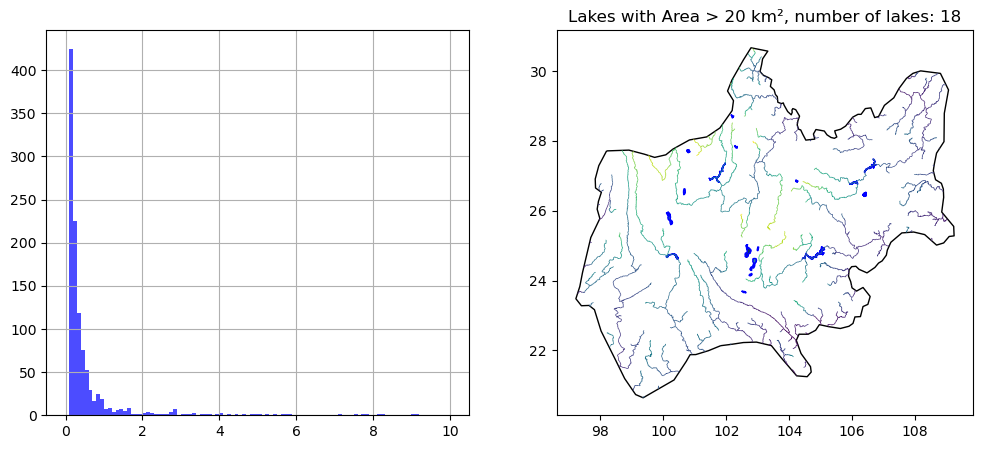

In [ ]:
lake_area_thredold = 20
lake_large_ygp = lake_ygp_gdf[lake_ygp_gdf.Lake_area > lake_area_thredold]
fig, axs = plt.subplots(1,2, figsize=(12, 5))
lake_ygp_gdf.Lake_area.hist(bins=100, color='blue', alpha=0.7, range=(0, 10), ax=axs[0])
lake_large_ygp.plot(column='Lake_area', ax=axs[1], cmap='Blues', edgecolor='blue')
ygp_gdf.plot(facecolor='none', edgecolor='black', ax=axs[1]) 
river_ygp_gdf.plot(column='wse', ax=axs[1], linewidth=0.5) 
axs[1].set_title('Lakes with Area > {} km², number of lakes: {}'.format(lake_area_thredold, len(lake_large_ygp))) 


### basins

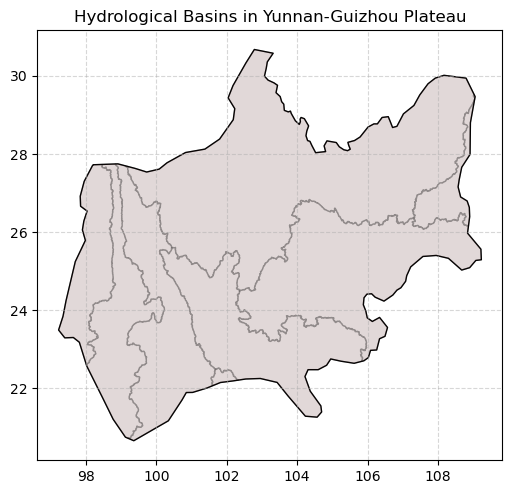

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
plt.rcParams.update({'font.size':10})
ygp_gdf.plot(ax=ax, facecolor='none', edgecolor='black')
basin_ygp_gdf.plot(ax=ax, facecolor="#693D3D", 
                   edgecolor="#000000", linewidth=1, alpha=0.2)  
ax.grid(True, linestyle='--', alpha=0.5) 
ax.set_title('Hydrological Basins in Yunnan-Guizhou Plateau') 
fig.savefig('figs/basins_ygp.png', dpi=300, bbox_inches='tight')
